## Iris is the classic first classification project every ML engineer does. The goal is:

- Given 4 measurements of a flower (sepal length, sepal width, petal length, petal width), predict which of 3 species it is — Setosa, Versicolor, or Virginica.

- So after EDA you'll do things Titanic never touched:

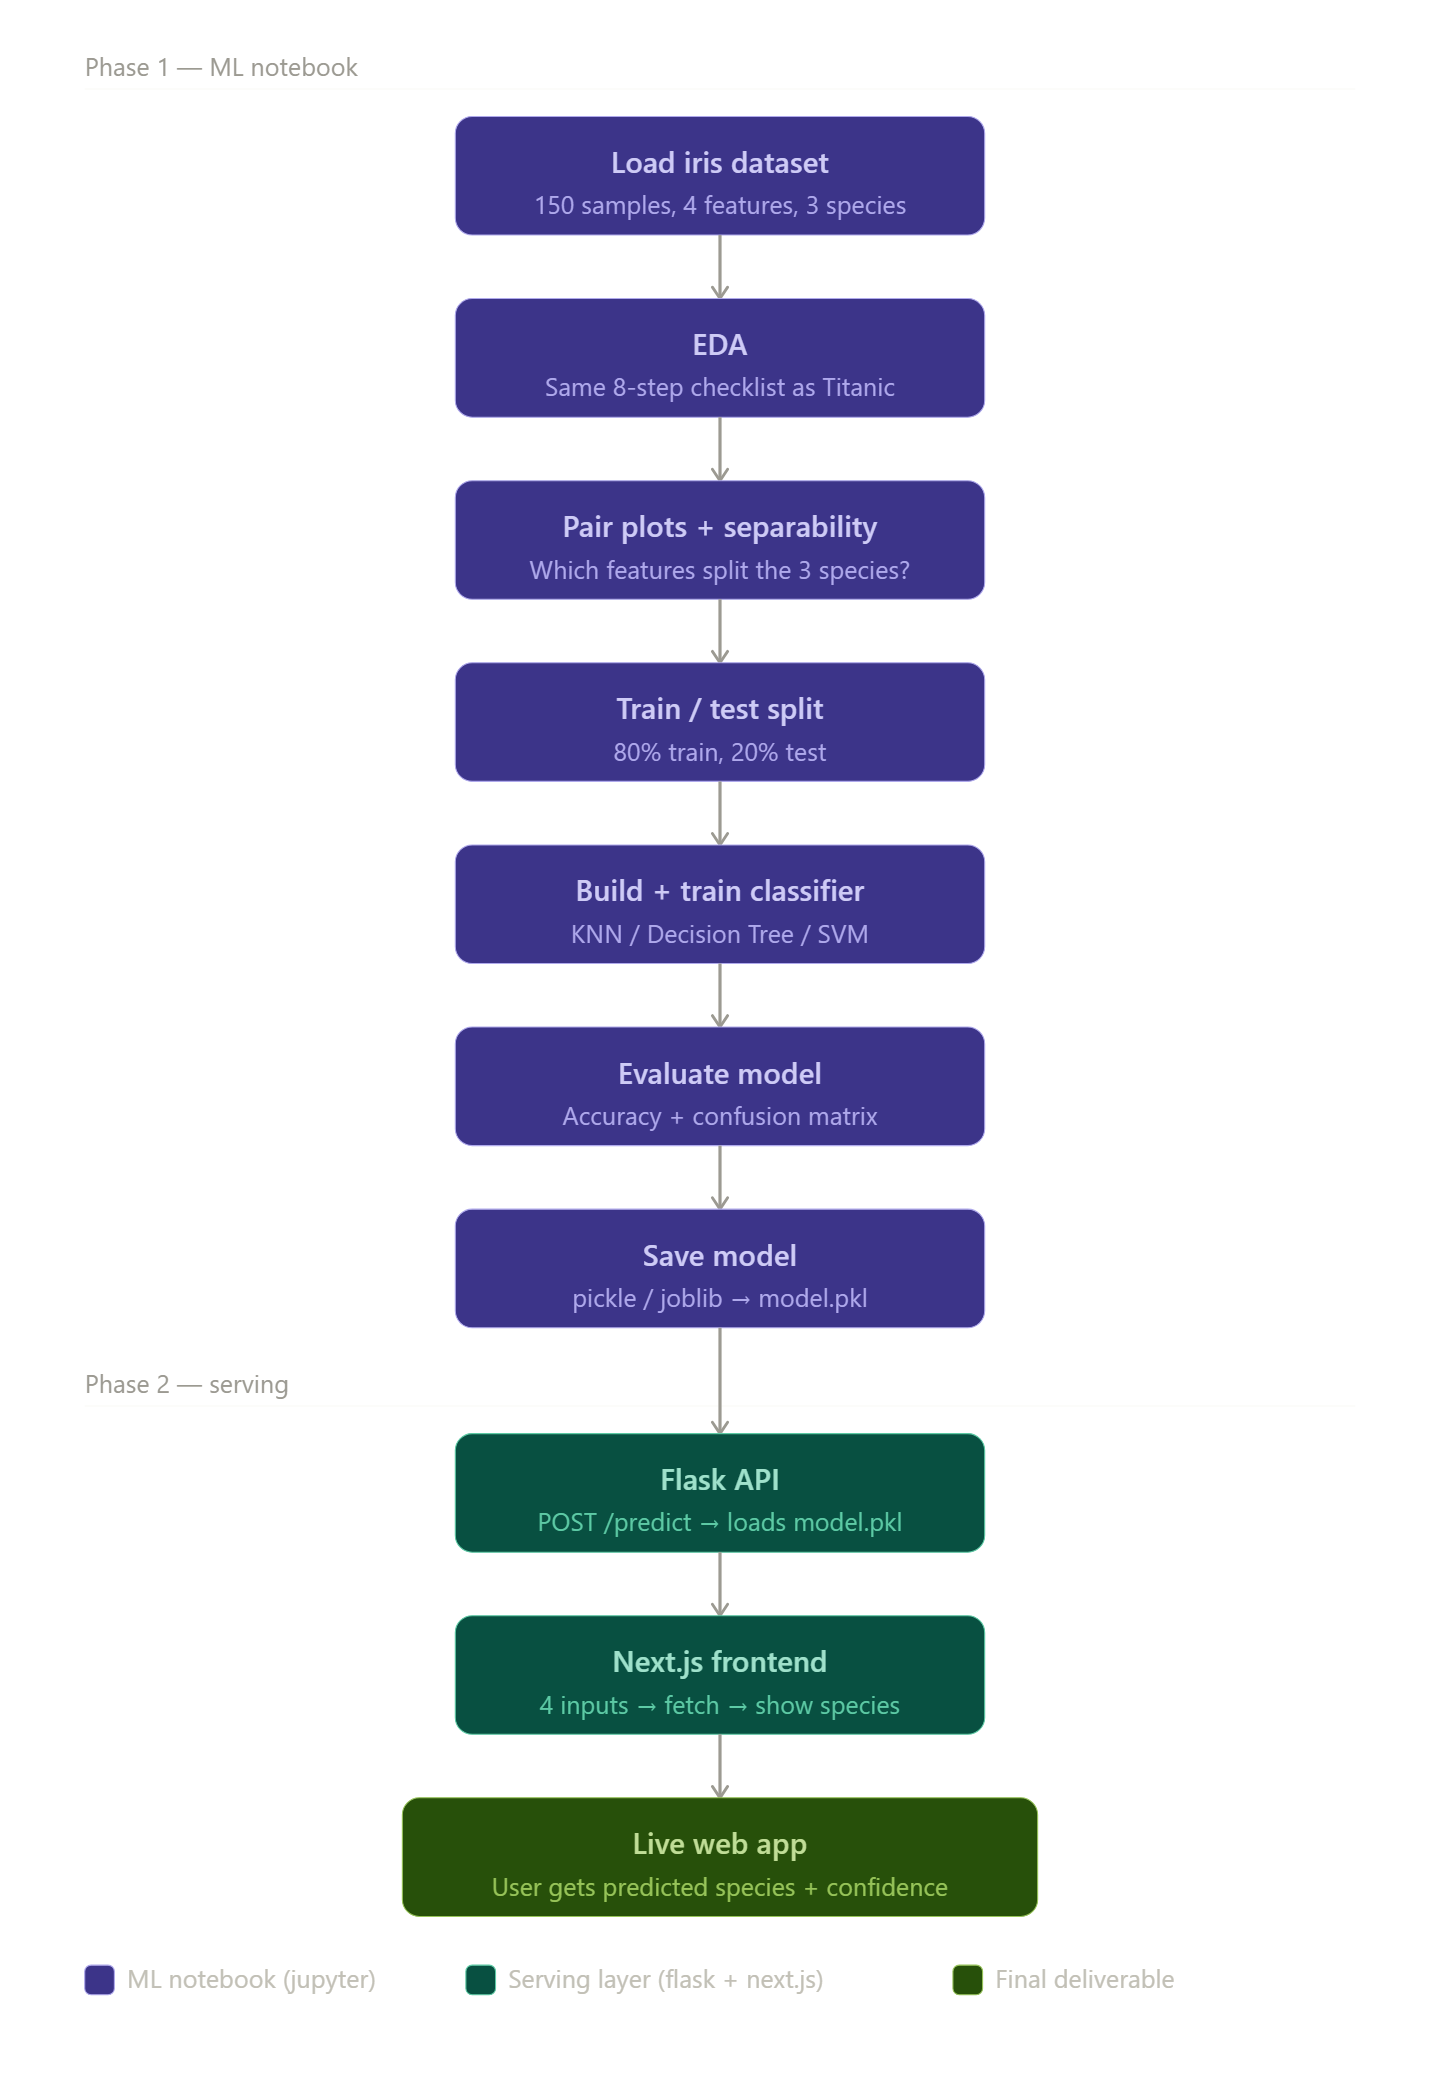

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

%matplotlib inline
sns.set_theme(style="whitegrid")

print("Libraries Loaded!")

Libraries Loaded!


In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)

df['species'] = iris.target

df['species'] = df['species'].map({0: 'setosa', 1:'versicolor', 2:'virginica'})

print("Shape: ", df.shape)

print(df.head())
print(df.tail())
print(df.info())
print(df.describe())

Shape:  (150, 5)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9         

In [3]:
df.info()
df.describe()
df['species'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

# Section 3 — Missing Values Audit will be the fastest section of your life:

In [4]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


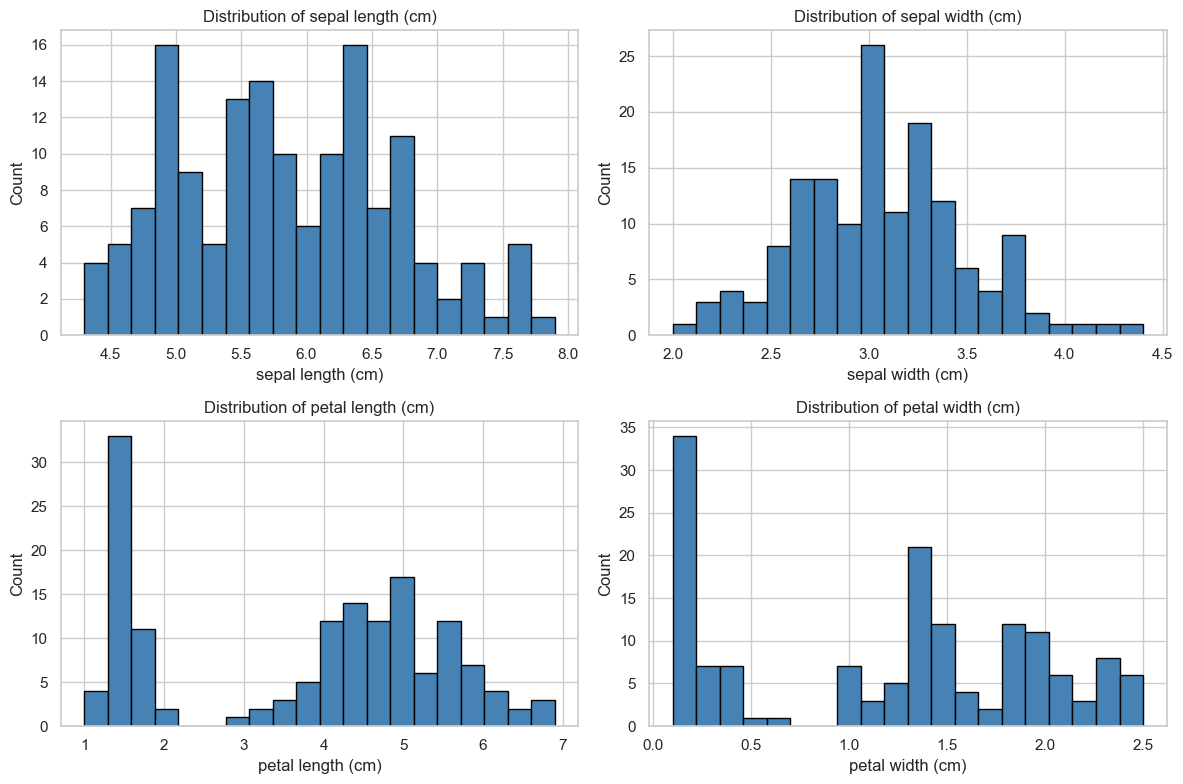

In [5]:
numeric_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()

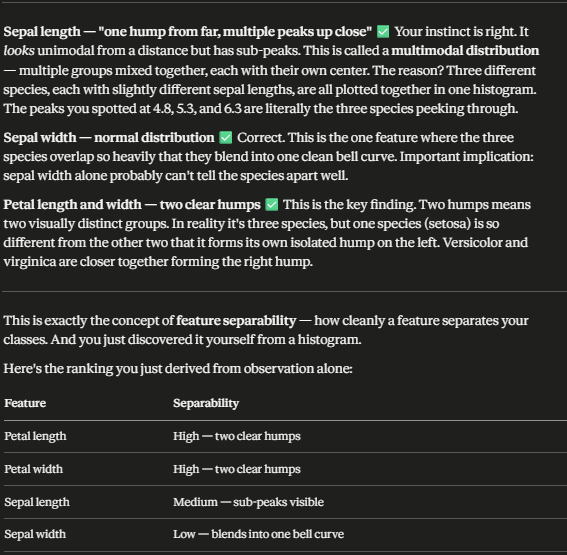

# Section 5 — The Pair Plot
This is the plot that makes Iris famous. One single function call that shows every feature against every other feature, colored by species.

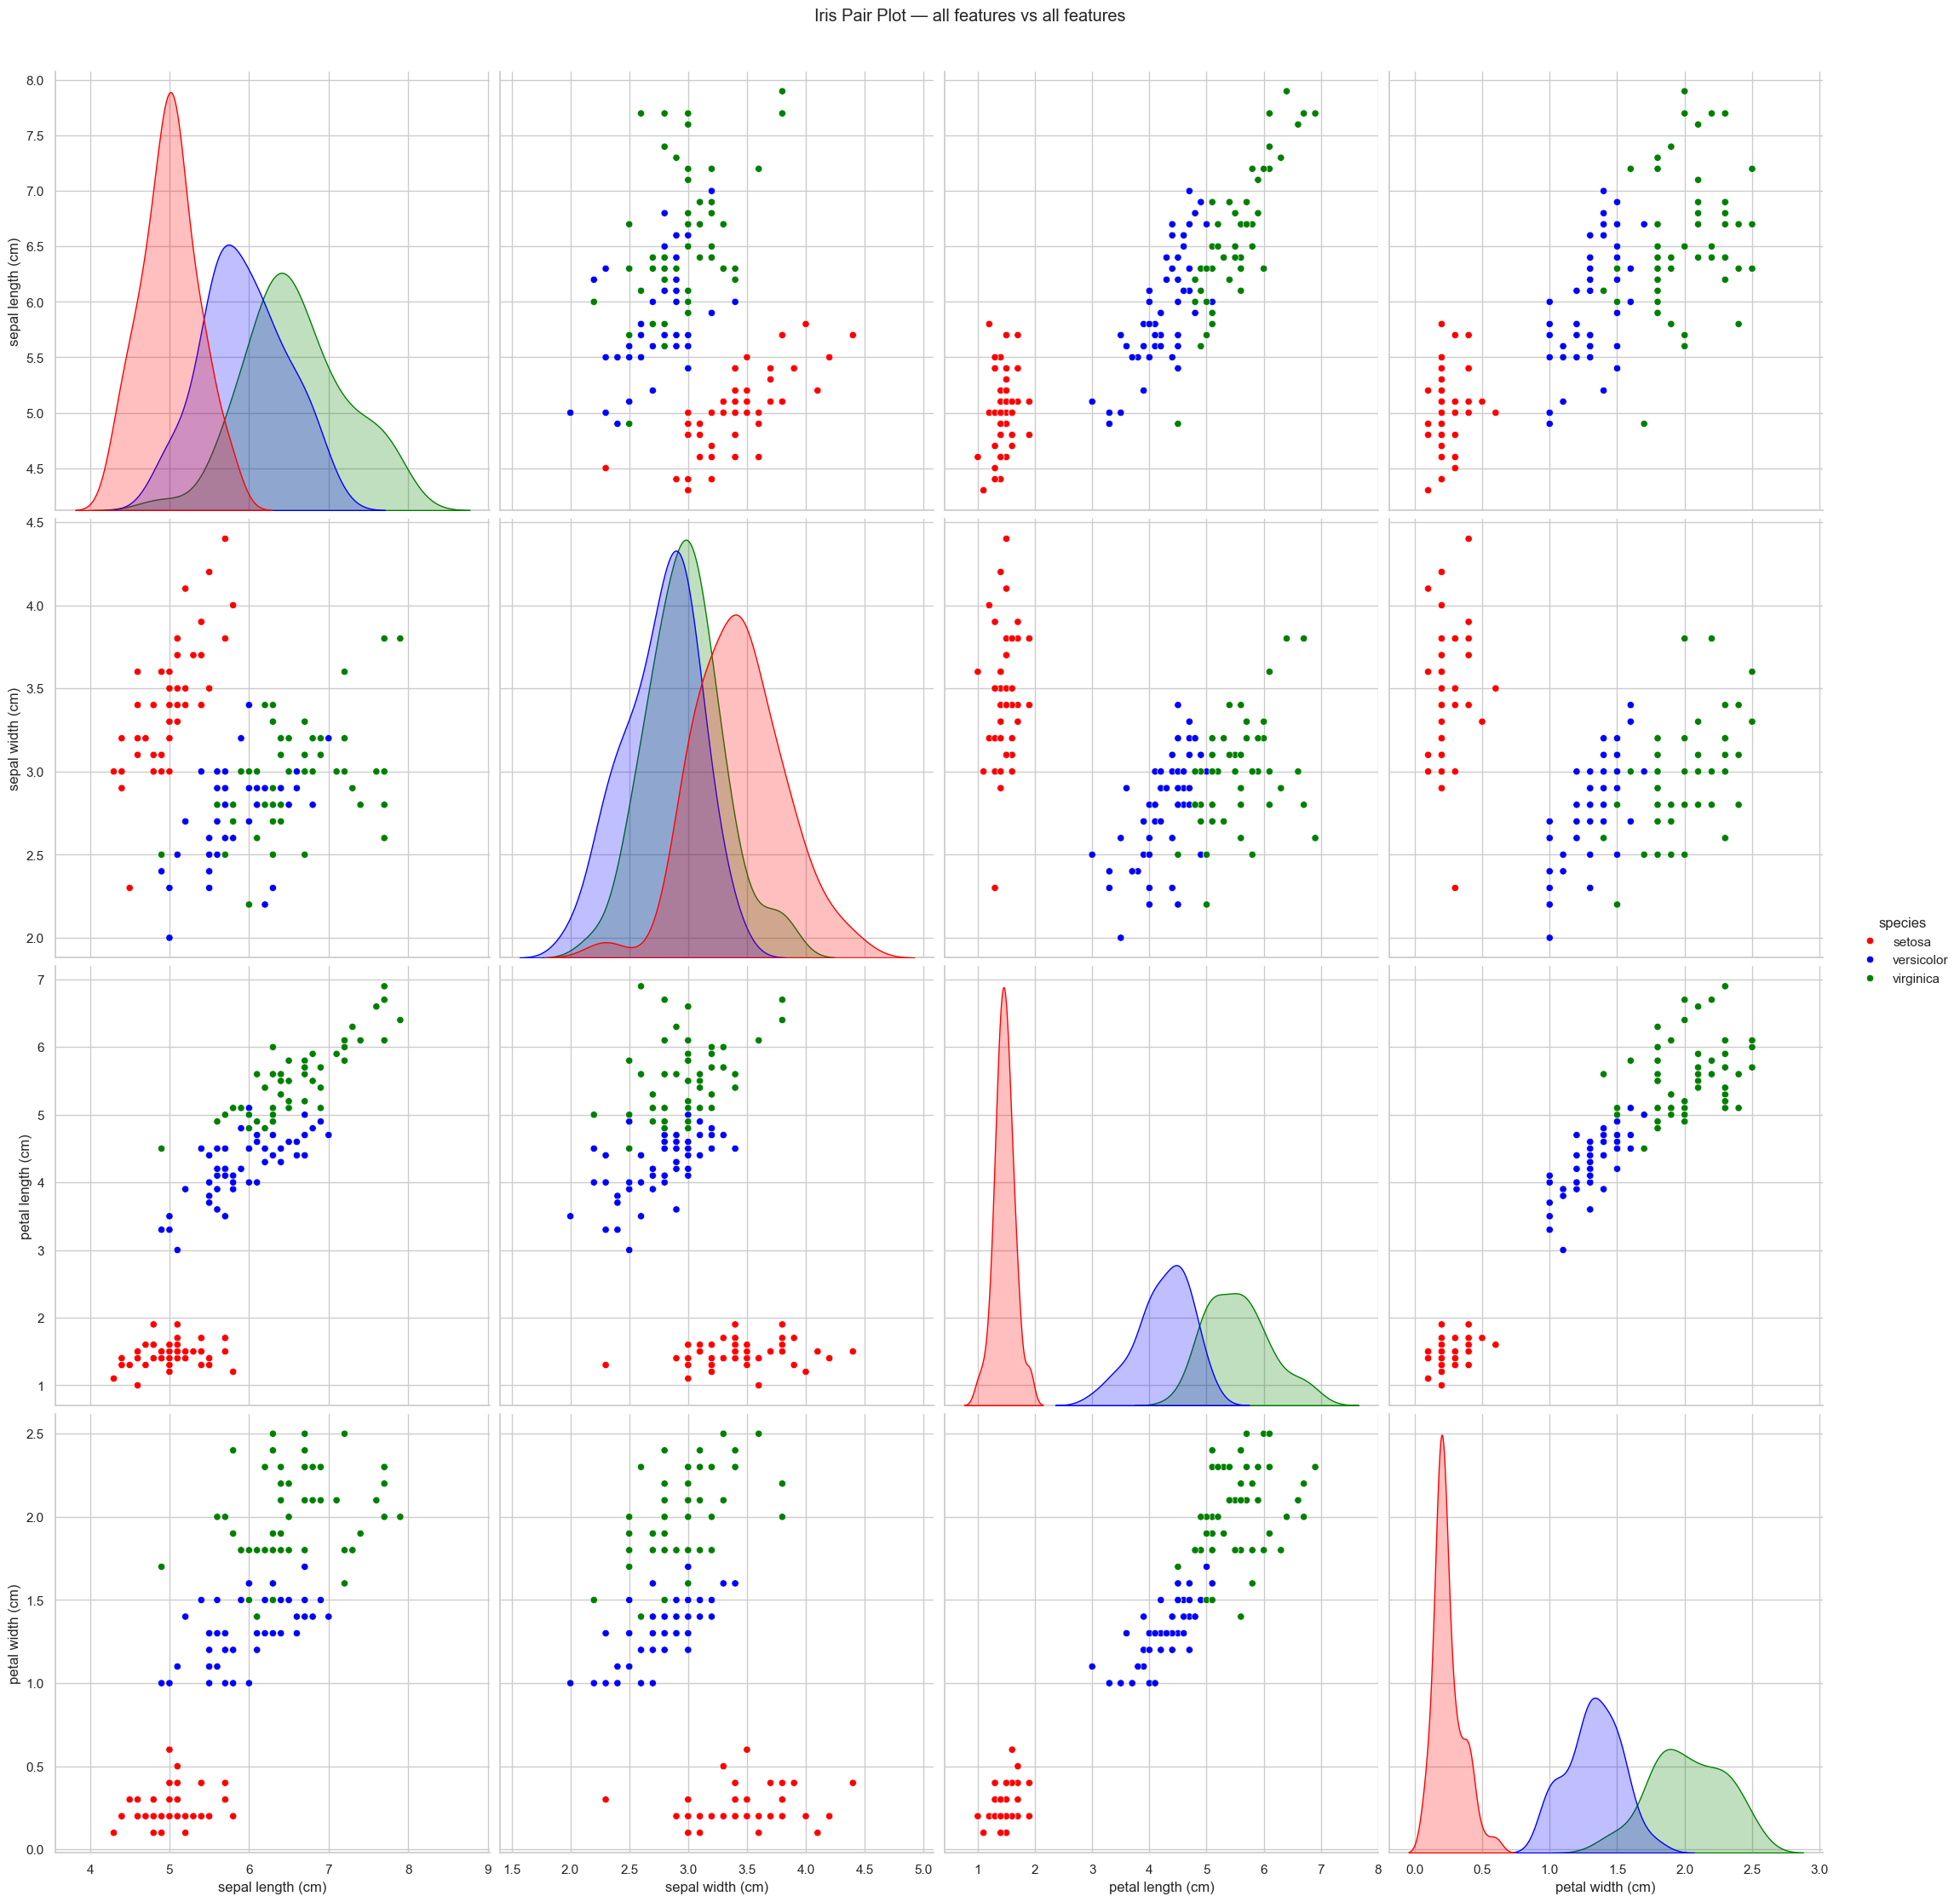

In [6]:
sns.pairplot(df, hue='species', height=5.5, 
             palette={'setosa': 'red', 
                      'versicolor': 'blue', 
                      'virginica': 'green'})
plt.suptitle('Iris Pair Plot — all features vs all features', y=1.02)
plt.show()

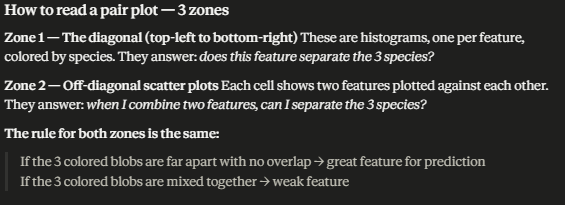
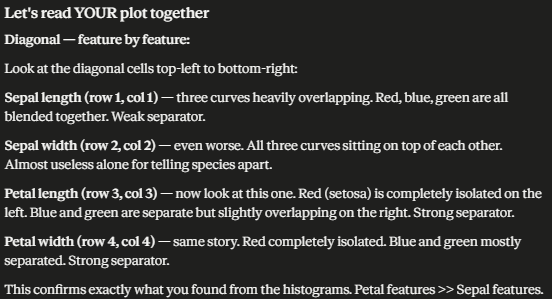
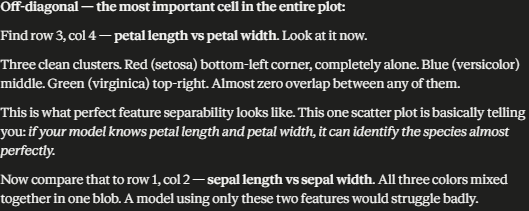

# The one-line summary of the entire pair plot

- Petal length + petal width = almost perfect species separator
- Sepal length + sepal width = poor separator, too much overlap

- The pair plot is a feature selection tool disguised as a visualisation. You're visually answering the question every ML engineer asks before building a model:
- "Which features actually carry signal for my prediction task?"

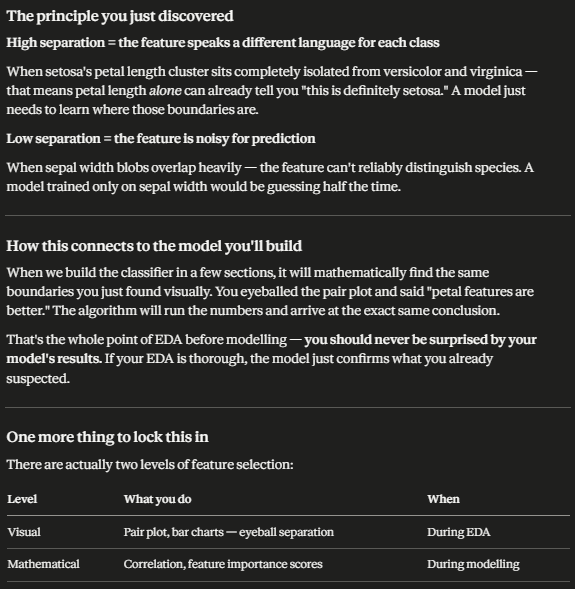

In [7]:
df.groupby('species').mean().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


In [8]:
df.groupby('species').std().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,0.35,0.38,0.17,0.11
versicolor,0.52,0.31,0.47,0.20
virginica,0.64,0.32,0.55,0.27


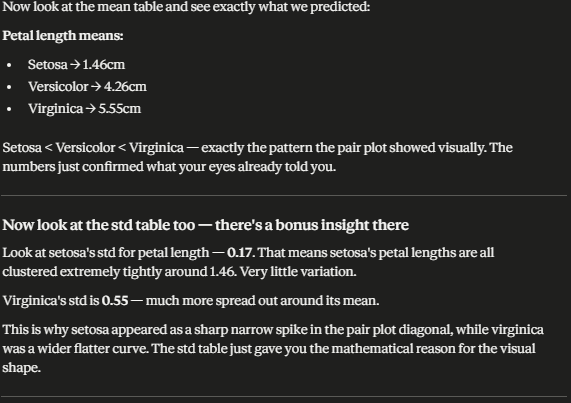

# The complete EDA picture so far
## You now know:

- Clean dataset, no missing values
- 50 samples per species — perfectly balanced
- Petal length and petal width are your strongest predictors — wide gap between species means, low overlap in the pair plot
- Setosa is the easiest to classify — sits completely isolated, tiny std
- Versicolor and virginica are harder — closer means, more overlap

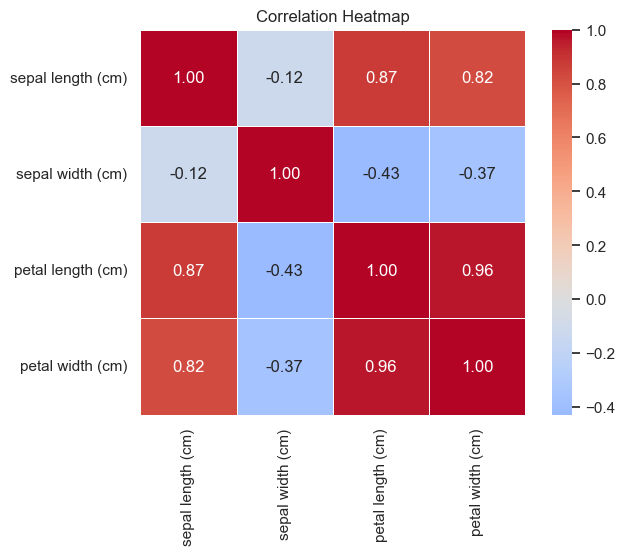

In [9]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

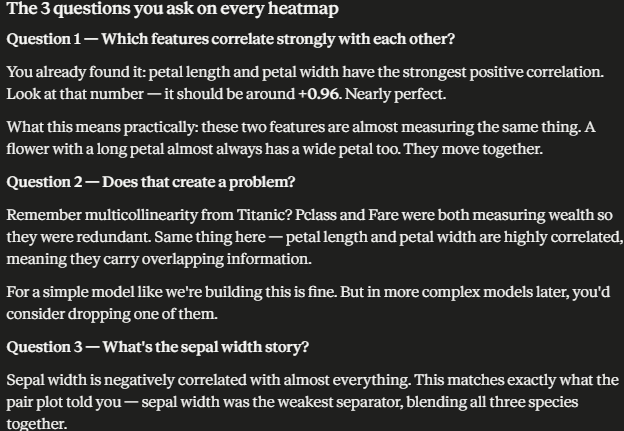

# The one takeaway from this heatmap

Petal length and petal width are not just good predictors individually — they're also measuring the same underlying thing (flower size). Sepal width is the odd one out, weakly related to everything else.

# ============================================
# IRIS EDA — KEY FINDINGS
# ============================================

# DATASET
- 150 samples, 4 features, 3 species
- Perfectly balanced — 50 samples per species
- Zero missing values — cleanest dataset you'll ever see

# FEATURE SEPARABILITY (from pair plot)
- Petal length → strong separator (setosa fully isolated)
- Petal width  → strong separator (setosa fully isolated)
- Sepal length → medium separator (some overlap)
- Sepal width  → weak separator  (heavy overlap)

# MEAN PETAL LENGTH PER SPECIES
- Setosa     → 1.46cm  (tiny, isolated)
- Versicolor → 4.26cm  (medium)
- Virginica  → 5.55cm  (largest)

# CORRELATION INSIGHTS
- Petal length vs petal width → +0.96 (nearly identical signal)
- Sepal width vs everything   → weak negative (noisy feature)

# CLASSIFICATION DIFFICULTY
- Setosa     → easiest  (completely isolated cluster)
- Versicolor → harder   (overlaps with virginica)
- Virginica  → harder   (overlaps with versicolor)

# PREDICTION STRATEGY
- Use petal length + petal width as primary features
- Model should nail setosa, struggle slightly on versi vs virg

# Phase 2 — Building the Model

Why do we split data at all?
- Imagine you give a student the exam questions a week before the exam. They memorise the answers. On exam day they score 100% — but they learned nothing, they just memorised.
- That's exactly what happens if you train and test a model on the same data. It memorises the answers instead of learning the pattern.
- The split fixes this:
Training data → the model studies from this (80%)
Test data     → the exam the model has never seen (20%)
- The test score is the only honest measure of how good your model actually is.

In [13]:
from sklearn.model_selection import train_test_split

X = df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples: ", len(X_train))
print("Test Samples: ", len(X_test))

Training samples:  120
Test Samples:  30


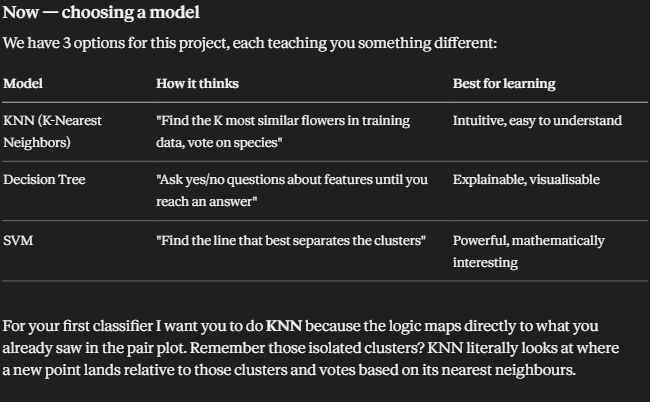

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 5)

knn.fit(X_train, y_train)

print("Model Trained!")

Model Trained!


In [16]:
y_pred = knn.predict(X_test)
print("Predictions: ", y_pred[:10])
print("Actual: ", list(y_test[:10]))

Predictions:  ['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor']
Actual:  ['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor', 'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor']


In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy: .2f}\n")
print(classification_report(y_test, y_pred))

Accuracy:  1.00

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



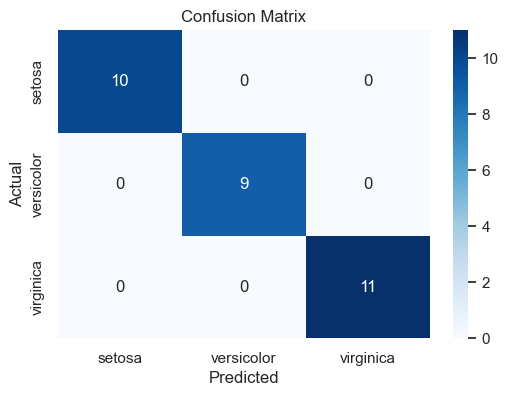

In [19]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred, labels=['setosa', 'versicolor', 'virginica'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['setosa', 'versicolor', 'virginica'], yticklabels=['setosa', 'versicolor', 'virginica'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [23]:
X_weak = df[['sepal length (cm)', 'sepal width (cm)']]

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_weak, y, test_size=0.2, random_state=42)

knn_weak = KNeighborsClassifier(n_neighbors=5)
knn_weak.fit(X_train_w, y_train_w)
y_pred_weak = knn_weak.predict(X_test_w)

print(accuracy_score(y_test_w, y_pred_weak))
print(accuracy)

0.8
1.0


# Now let's save the model
This is the bridge between the notebook and Flask. You train the model once, save it to disk, and Flask loads it every time someone makes a prediction. You never retrain in production.

In [24]:
import joblib
joblib.dump(knn, 'iris_model.pkl')
print("Model saved as iris_model.pkl")

Model saved as iris_model.pkl


In [26]:
model = joblib.load('iris_model.pkl')
test_prediction = model.predict([[5.1, 3.5, 1.4, 0.2]])
print(test_prediction)

['setosa']


C:\Users\Shantanu Khosla\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


# The notebook is done. Here's everything you built:
- ✅ EDA          — understood the dataset fully before touching a model
- ✅ Pair plot    — identified petal features as strongest predictors  
- ✅ Train/test   — honest evaluation on unseen data
- ✅ KNN model    — 100% accuracy on test set
- ✅ Stress test  — proved EDA conclusions were correct (100% → 80%)
- ✅ Saved model  — iris_model.pkl ready for serving